In [1]:
# Classes

import numpy as np

class F:
    
    @staticmethod
    def ReLU(x):
        """
        Rectified Linear Unit.
        If a number is less than 0, it becomes 0. Otherwise, it stays the same.
        """
        # np.maximum compares every element with 0 and keeps the higher one
        return np.maximum(0, x)

    @staticmethod
    def Sigmoid(x):
        """
        Squishes every number in the matrix into a decimal between 0 and 1.
        Perfect for binary classification.
        """
        return 1.0 / (1.0 + np.exp(-x))

    @staticmethod
    def Tanh(x):
        """
        Squishes every number between -1 and 1. 
        """
        # Writing out the raw math formula for Tanh!
        return (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))

    @staticmethod
    def Softmax(x):
        """
        Turns an array of raw scores into probabilities that all add up to exactly 1.0.
        """
        # Subtract the max value for numerical stability
        # In NumPy, 'dim' is called 'axis'
        shifted_x = x - np.max(x, axis=-1, keepdims=True)
        
        exp_x = np.exp(shifted_x)
        
        # Divide each exponent by the sum of all exponents
        return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

# ==========================================
# 1. CORE MATHEMATICS ENGINE
# ==========================================
class NuralMaths:
    """Provides low-level mathematical operations and weight initializations."""
    
    @staticmethod
    def neuralNet(map_weights, map_biases):
        """Initializes weight and bias matrices with scaled random values for network stability."""
        weights = np.random.randn(*map_weights) * 0.01
        biases = np.random.randn(*map_biases) * 0.01
        return weights, biases

    @staticmethod
    def Neuron(input_matrix, weight_matrix, bias):
        """Computes the activation of a single connection."""
        return (input_matrix * weight_matrix) + bias

    @staticmethod
    def CNeuron(input_matrix, weight_matrix, bias):
        """Computes the dot product sum and adds the bias for spatial feature extraction."""
        dot_product_sum = np.sum(input_matrix * weight_matrix)
        return dot_product_sum + np.sum(bias)


# ==========================================
# 2. BASE MODULE ARCHITECTURE
# ==========================================
class Module:
    """The base class inherited by all neural network layers. Manages training states and forward routing."""
    
    def __init__(self):
        self.training = True  # Indicates whether the network is in training or evaluation mode.

    def __call__(self, x):
        """Allows instances to be called as functions, routing inputs to the forward method."""
        return self.forward(x)

    def forward(self, x):
        """Placeholder for the forward pass, to be overridden by subclasses."""
        raise NotImplementedError

    def backward(self, d_out):
        """Placeholder for the backward pass, to be overridden by subclasses."""
        raise NotImplementedError

    def train(self):
        """Sets the module and all internal behaviors to training mode."""
        self.training = True

    def eval(self):
        """Sets the module to evaluation mode, disabling layers like Dropout."""
        self.training = False


# ==========================================
# 3. NETWORK LAYERS
# ==========================================
class Linear(Module):
    """A fully connected (dense) layer that applies a linear transformation to the incoming data."""
    
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weights, self.biases = NuralMaths.neuralNet((out_features, in_features), (out_features, 1))
        
        # Memory allocation for gradients and inputs
        self.d_weights = np.zeros_like(self.weights)
        self.d_biases = np.zeros_like(self.biases)
        self.inputs = None 

    def forward(self, x):
        """Performs matrix multiplication on the input and adds the bias."""
        self.inputs = x 
        return np.dot(self.weights, x) + self.biases.flatten()

    def backward(self, d_out):
        """Computes the gradients for weights and biases, and propagates the error backward."""
        # Reshape inputs to ensure correct matrix multiplication dimensions
        inputs_reshaped = self.inputs.reshape(1, -1)
        d_out_reshaped = d_out.reshape(-1, 1)

        self.d_weights = np.dot(d_out_reshaped, inputs_reshaped)
        self.d_biases = np.sum(d_out_reshaped, axis=1, keepdims=True)
        
        d_inputs = np.dot(self.weights.T, d_out)
        return d_inputs


class Conv2d(Module):
    """A 2D convolutional layer that extracts spatial features using a sliding window."""
    
    def __init__(self, in_channels, out_channels, kernel_size, padding=0, stride=1):
        super().__init__()
        self.kernel_size = kernel_size
        self.padding = padding
        self.stride = stride
        self.out_channels = out_channels
        
        self.weights, self.biases = NuralMaths.neuralNet(
            (out_channels, in_channels, kernel_size, kernel_size), 
            (out_channels, 1)
        )
        
        self.d_weights = np.zeros_like(self.weights)
        self.d_biases = np.zeros_like(self.biases)
        self.inputs = None
        self.padded_input = None

    def forward(self, inputs):
        """Slides the convolutional filters across the input grid to generate feature maps."""
        self.inputs = inputs
        C, H, W = inputs.shape
        
        out_h = int((H + 2 * self.padding - self.kernel_size) / self.stride) + 1
        out_w = int((W + 2 * self.padding - self.kernel_size) / self.stride) + 1
        output = np.zeros((self.out_channels, out_h, out_w))
        
        if self.padding > 0:
            self.padded_input = np.pad(inputs, 
                                  ((0, 0), (self.padding, self.padding), (self.padding, self.padding)), 
                                  mode='constant', constant_values=0)
        else:
            self.padded_input = inputs

        for f in range(self.out_channels):
            for i in range(out_h):
                for j in range(out_w):
                    h_start, h_end = i * self.stride, i * self.stride + self.kernel_size
                    w_start, w_end = j * self.stride, j * self.stride + self.kernel_size
                    
                    image_chunk = self.padded_input[:, h_start:h_end, w_start:w_end]
                    output[f, i, j] = NuralMaths.CNeuron(image_chunk, self.weights[f], self.biases[f])
                    
        return output

    def backward(self, d_out):
        """Applies the spatial chain rule to compute weight gradients and input errors."""
        self.d_weights.fill(0)
        self.d_biases.fill(0)
        d_padded_input = np.zeros_like(self.padded_input)
        
        out_h, out_w = d_out.shape[1], d_out.shape[2]

        for f in range(self.out_channels):
            self.d_biases[f] = np.sum(d_out[f])
            
            for i in range(out_h):
                for j in range(out_w):
                    h_start, h_end = i * self.stride, i * self.stride + self.kernel_size
                    w_start, w_end = j * self.stride, j * self.stride + self.kernel_size
                    
                    image_patch = self.padded_input[:, h_start:h_end, w_start:w_end]
                    
                    self.d_weights[f] += image_patch * d_out[f, i, j]
                    d_padded_input[:, h_start:h_end, w_start:w_end] += self.weights[f] * d_out[f, i, j]

        # Removes the padding from the error grid before returning
        if self.padding > 0:
            p = self.padding
            d_inputs = d_padded_input[:, p:-p, p:-p]
        else:
            d_inputs = d_padded_input

        return d_inputs


class MaxPool2d(Module):
    """Downsamples spatial dimensions by retaining only the maximum value within the pooling window."""
    
    def __init__(self, kernel_size, stride):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride
        self.inputs = None

    def forward(self, inputs):
        """Extracts the largest value from each defined spatial window."""
        self.inputs = inputs
        C, H, W = inputs.shape
        
        out_h = int((H - self.kernel_size) / self.stride) + 1
        out_w = int((W - self.kernel_size) / self.stride) + 1
        output = np.zeros((C, out_h, out_w))
        
        for c in range(C):
            for i in range(out_h):
                for j in range(out_w):
                    h_start, h_end = i * self.stride, i * self.stride + self.kernel_size
                    w_start, w_end = j * self.stride, j * self.stride + self.kernel_size
                    
                    image_chunk = inputs[c, h_start:h_end, w_start:w_end]
                    output[c, i, j] = np.max(image_chunk)
                    
        return output

    def backward(self, d_out):
        """Routes the incoming error solely to the pixel that held the maximum value during the forward pass."""
        d_inputs = np.zeros_like(self.inputs)
        C, out_h, out_w = d_out.shape

        for c in range(C):
            for i in range(out_h):
                for j in range(out_w):
                    h_start, h_end = i * self.stride, i * self.stride + self.kernel_size
                    w_start, w_end = j * self.stride, j * self.stride + self.kernel_size
                    
                    image_chunk = self.inputs[c, h_start:h_end, w_start:w_end]
                    max_val = np.max(image_chunk)
                    
                    # Generates a boolean mask locating the maximum value
                    mask = (image_chunk == max_val)
                    
                    # Applies the error only to the active pixel
                    d_inputs[c, h_start:h_end, w_start:w_end] += mask * d_out[c, i, j]

        return d_inputs


class Flatten(Module):
    """Reshapes multidimensional spatial tensors into 1D arrays for fully connected layers."""
    
    def __init__(self):
        super().__init__()
        self.input_shape = None

    def forward(self, x):
        """Flattens the array while storing original dimensions in memory."""
        self.input_shape = x.shape
        return x.flatten()

    def backward(self, d_out):
        """Reconstructs the 3D/4D structure of the error gradients."""
        return d_out.reshape(self.input_shape)


class ReLU(Module):
    """Applies the Rectified Linear Unit activation function."""
    
    def __init__(self):
        super().__init__()
        self.inputs = None

    def forward(self, x):
        """Nullifies values below zero and passes positive values unchanged."""
        self.inputs = x
        return np.maximum(0, x)

    def backward(self, d_out):
        """Stops error propagation for values that were nullified during the forward pass."""
        return d_out * (self.inputs > 0)


class Dropout(Module):
    """Randomly zeroes out elements to prevent network overfitting."""
    
    def __init__(self, p=0.5):
        super().__init__()
        self.p = p 
        self.mask = None

    def forward(self, x):
        """Generates a binary mask and scales the active neurons during training."""
        if self.training:
            self.mask = (np.random.rand(*x.shape) > self.p)
            return (x * self.mask) / (1.0 - self.p)
        else:
            return x

    def backward(self, d_out):
        """Applies the saved binary mask to the incoming error gradients."""
        if self.training:
            return (d_out * self.mask) / (1.0 - self.p)
        else:
            return d_out


# ==========================================
# 4. OPTIMIZATION AND LOSS
# ==========================================
class CrossEntropyLoss:
    """Measures prediction error against true categorical labels."""
    
    def __init__(self):
        self.predictions = None
        self.targets = None

    def forward(self, predictions, targets):
        """Computes the logarithmic loss penalty."""
        self.predictions = predictions
        self.targets = targets
        epsilon = 1e-9 # Stability constant to prevent log(0) errors
        loss = -np.sum(targets * np.log(predictions + epsilon))
        return loss

    def backward(self):
        """Calculates the derivative of the loss function."""
        return self.predictions - self.targets


class SGD:
    """Stochastic Gradient Descent optimizer responsible for weight updates."""
    
    def __init__(self, layers, lr=0.001):
        self.layers = layers
        self.lr = lr

    def step(self):
        """Iterates through layers and applies the gradient penalty to the weights."""
        for layer in self.layers:
            if hasattr(layer, 'weights'):
                layer.weights -= (self.lr * layer.d_weights)
                layer.biases -= (self.lr * layer.d_biases)

    def zero_grad(self):
        """Clears accumulated gradients before the next training iteration."""
        for layer in self.layers:
            if hasattr(layer, 'weights'):
                layer.d_weights.fill(0)
                layer.d_biases.fill(0)


class ReLU(Module):
    """Applies the Rectified Linear Unit activation function."""
    
    def __init__(self):
        super().__init__()
        self.inputs = None

    def forward(self, x):
        """Passes the input through our Functional API."""
        self.inputs = x
        return F.ReLU(x)

    def backward(self, d_out):
        """Stops error propagation for values that were nullified during the forward pass."""
        return d_out * (self.inputs > 0)

class Sigmoid(Module):
    def forward(self, x):
        self.inputs = x
        return F.Sigmoid(x)

    def backward(self, d_out):
        # Derivative of Sigmoid is: Sigmoid(x) * (1 - Sigmoid(x))
        s = F.Sigmoid(self.inputs)
        return d_out * (s * (1 - s))

class Tanh(Module):
    def forward(self, x):
        self.inputs = x
        return F.Tanh(x)

    def backward(self, d_out):
        # Derivative of Tanh is: 1 - Tanh(x)^2
        t = F.Tanh(self.inputs)
        return d_out * (1 - t**2)

class Softmax(Module):
    def forward(self, x):
        self.inputs = x
        return F.Softmax(x)

    def backward(self, d_out):
        # Note: In most frameworks, Softmax is combined with CrossEntropy 
        # to simplify the backward pass to (Predictions - Targets).
        return d_out

In [2]:
from sklearn.datasets import fetch_openml

print("Loading MNIST data...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

# Use 1,000 for training and 500 for testing
train_data = mnist.data[:1000]
test_data = mnist.data[1000:1500]

train_labels_raw = mnist.target[:1000].astype(int)
test_labels_raw = mnist.target[1000:1500].astype(int)

# Normalize and reshape
train_images = train_data.reshape(-1, 1, 28, 28) / 255.0
test_images = test_data.reshape(-1, 1, 28, 28) / 255.0

# Convert labels to One-Hot
train_labels = np.eye(10)[train_labels_raw]
test_labels = np.eye(10)[test_labels_raw]

print(f"New Training set size: {train_images.shape[0]}")
print(f"New Test set size: {test_images.shape[0]}")

Loading MNIST data...
New Training set size: 1000
New Test set size: 500


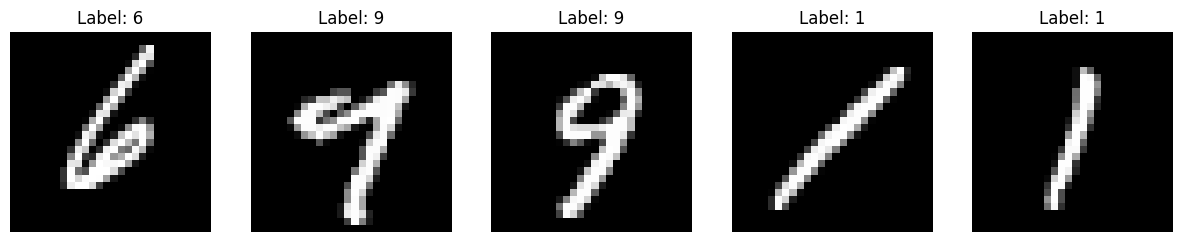

In [3]:
import matplotlib.pyplot as plt

# Display 5 random images
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
indices = np.random.choice(len(train_images), 5, replace=False)

for idx, ax in enumerate(axes):
    # Reshape back to 28x28 for plotting
    ax.imshow(train_images[indices[idx]].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {np.argmax(train_labels[indices[idx]])}")
    ax.axis('off')
plt.show()

In [4]:
class MNIST_CNN(Module):
    def __init__(self):
        super().__init__()
        # 28x28x1 Input -> Conv Layer (8 filters)
        self.conv1 = Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)
        self.relu1 = ReLU()
        self.pool1 = MaxPool2d(kernel_size=2, stride=2)
        
        # Flatten: 8 channels * 14 * 14
        self.flatten = Flatten()
        
        # Fully Connected Layer: 1568 inputs -> 10 output classes
        self.fc1 = Linear(in_features=(8 * 14 * 14), out_features=10)

    def forward(self, x):
        # Pass data through the layers
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.flatten(x)
        x = self.fc1(x)
        return F.Softmax(x)

In [5]:
model = MNIST_CNN()
model.train()
criterion = CrossEntropyLoss()
optimizer = SGD(layers=[model.conv1, model.fc1], lr=0.01)

num_samples = len(train_images)
epochs = 5

for epoch in range(epochs):
    epoch_loss = 0
    correct = 0
    
    for i in range(num_samples):
        # 1. Forward Pass
        prediction = model(train_images[i])
        
        # 2. Loss Calculation
        loss = criterion.forward(prediction, train_labels[i])
        epoch_loss += loss
        
        # Check accuracy
        if np.argmax(prediction) == np.argmax(train_labels[i]):
            correct += 1
            
        # 3. Backward Pass
        d_out = criterion.backward()
        d_out = model.fc1.backward(d_out)
        d_out = model.flatten.backward(d_out)
        d_out = model.pool1.backward(d_out)
        d_out = model.relu1.backward(d_out)
        d_out = model.conv1.backward(d_out)
        
        # 4. Update Weights
        optimizer.step()
        optimizer.zero_grad()

    print(f"Epoch {epoch+1} | Loss: {epoch_loss/num_samples:.4f} | Accuracy: {(correct/num_samples)*100:.2f}%")

print("Training Complete!")

Epoch 1 | Loss: 1.3458 | Accuracy: 56.10%
Epoch 2 | Loss: 0.5249 | Accuracy: 84.60%
Epoch 3 | Loss: 0.4189 | Accuracy: 87.10%
Epoch 4 | Loss: 0.3603 | Accuracy: 88.80%
Epoch 5 | Loss: 0.3167 | Accuracy: 90.80%
Training Complete!



--- Running Evaluation on Test Set ---

--- High-Confidence Errors ---


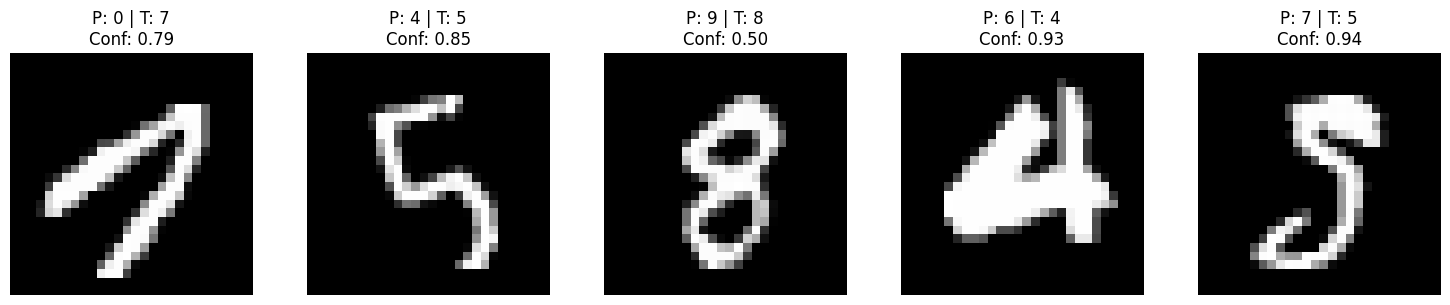


--- High-Confidence Corrects ---


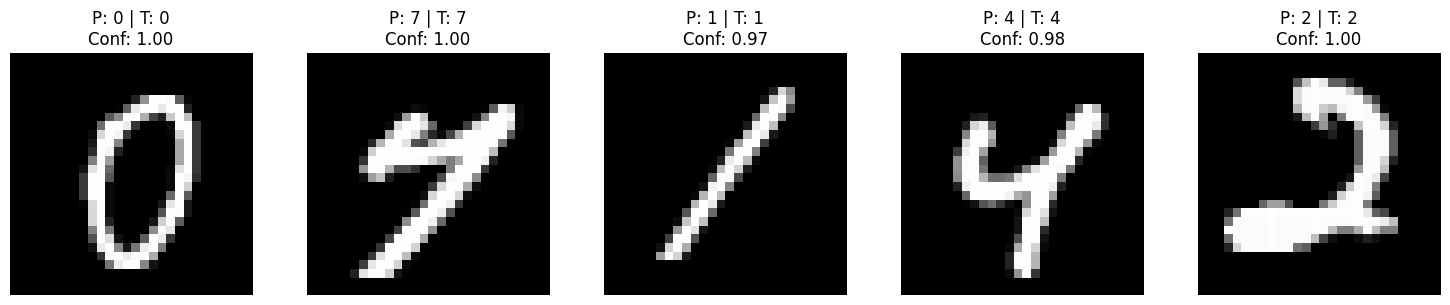

In [6]:
model.eval()
wrong_predictions = []
correct_predictions = []

print("\n--- Running Evaluation on Test Set ---")
for i in range(len(test_images)):
    # 1. Forward Pass (No backward/training needed)
    prediction = model(test_images[i])
    
    # 2. Extract results
    pred_idx = np.argmax(prediction)
    true_idx = np.argmax(test_labels[i])
    confidence = np.max(prediction)
    
    # 3. Categorize results based on confidence
    # Error: Wrong prediction with high certainty
    if pred_idx != true_idx and confidence > 0.5:
        wrong_predictions.append((i, pred_idx, true_idx, confidence))
    
    # Correct: Right prediction with high certainty
    elif pred_idx == true_idx and confidence > 0.9:
        correct_predictions.append((i, pred_idx, true_idx, confidence))

# --- Displaying Results ---
def show_results(data_list, title):
    if len(data_list) == 0:
        print(f"No {title} found.")
        return
        
    print(f"\n--- {title} ---")
    plt.figure(figsize=(15, 3))
    for i, (idx, pred, actual, conf) in enumerate(data_list[:5]):
        plt.subplot(1, 5, i + 1)
        # Reshape to (28, 28) to ensure proper visualization
        plt.imshow(test_images[idx].reshape(28, 28), cmap='gray')
        plt.title(f"P: {pred} | T: {actual}\nConf: {conf:.2f}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_results(wrong_predictions, "High-Confidence Errors")
show_results(correct_predictions, "High-Confidence Corrects")